<a href="https://colab.research.google.com/github/ShuAng1602/ADALL_Github/blob/main/CBA1C03_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
!pip -q install -U \
  scikit-learn==1.8.0
# Most stable version

In [70]:
# Core libraries
import pandas as pd
import numpy as np
# Visualisation
import matplotlib.pyplot as plt
# Modelling and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.inspection import permutation_importance

import xgboost as xgb
import sklearn

RANDOM_STATE = 42
print("Setup complete")

Setup complete


In [71]:
import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.8.0


In [72]:
github_raw_url = 'https://raw.githubusercontent.com/ShuAng1602/ADALL_Github/refs/heads/main/fraud_oracle.csv'
try:
    df = pd.read_csv(github_raw_url) # index_col=0) #when data is starting with index so start with 0
    print("Successfully loaded data from GitHub!")
    display(df.head()) # show top 5
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

Successfully loaded data from GitHub!


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [73]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [74]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [76]:
from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

In [77]:
import pandas as pd
import numpy as np
from io import StringIO
# ---------------------------
# Generate a full dataset profile
# ---------------------------
buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# unique cardinality
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

# correlation matrix
buffer.write("=== CORRELATIONS (NUMERIC ONLY) ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

# value counts for categoricals
buffer.write("=== VALUE COUNTS (TOP 20 PER CATEGORICAL COLUMN) ===\n")
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        buffer.write(f"\nColumn: {col}\n")
        vc = df[col].value_counts().head(20)
        buffer.write(vc.to_string())
        buffer.write("\n")
else:
    buffer.write("No categorical columns\n")
buffer.write("\n")

# --------- FIXED OUTLIER COMPUTATION (NO BOOLEANS) ---------
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# leakage scan: columns with all unique values
buffer.write("=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n")
leak_cols = df.columns[df.nunique() == len(df)]
buffer.write(str(list(leak_cols)))
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)

=== DTYPES ===
Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
PolicyNumber             int64
RepNumber                int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
NumberOfCars            object
Year                    

In [78]:
# sending to LLM API First Draft
response = client.responses.create(
    model="gpt-5-mini",
    instructions="""
You are an expert data scientist specialising in insurance analytics and fraud detection.
Use ONLY the information inside the provided dataset profile text.
Do NOT invent correlations, columns, distributions, or values.
If a detail is not explicitly present in the dataset profile, clearly state: 'Not shown in profile'.
Always justify reasoning and recommendations based ONLY on the dataset profile and business context.
Focus on clarity, business relevance, and modelling alignment.
""",
    input=f"""
    Dataset info: {payload_text}\n

    Context:
    The business problem relates to detecting fraudulent vehicle insurance claims.
    The dataset contains vehicle details, accident attributes, and insurance policy information.
    The target variable is FraudFound_P, where 1 indicates a fraudulent claim and 0 indicates a legitimate claim.

    Questions:
    1. Describe the business problem you aim to address. Explain why it matters and who is affected.

    2. Identify the key beneficiary of the ML solution. Create a simple persona that captures:
      - Goals
      - Pain points
      - Behaviours

    3. Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives.
      - What job is the user trying to complete?
      - What is the most appropriate target variable?
    """
    )

print(response.output_text)

1) Business problem — description and why it matters

- Problem statement: Build a model to detect fraudulent vehicle insurance claims (FraudFound_P = 1) using the available claim, vehicle and policy attributes in order to surface likely fraudulent claims for investigation.

- Why it matters:
  - The dataset shows fraud is a minority class (FraudFound_P mean = 0.059857 → ~6% of claims). Even at this prevalence, undetected fraud will erode insurer profitability and increase premiums for honest customers; over‑flagging legitimate claims wastes investigative capacity and harms customer experience. The insurer and its customers are therefore directly affected.
  - Key stakeholders impacted: claims operations (investigators/adjusters), fraud analytics team, underwriting/finance (losses and reserves), and policyholders (premiums / service experience).

- What the data enables: The profile contains rich features relevant to underwriting/claims (vehicle Make, VehicleCategory, VehiclePrice, Age

In [79]:
# sending to LLM API Refined Prompt
response = client.responses.create(
    model="gpt-5-mini",
    instructions="""
You are an expert data scientist specialising in insurance analytics and fraud detection.

Follow these rules strictly:
1. Use ONLY the information explicitly present in the provided dataset profile text.
2. Do NOT invent correlations, costs, KPIs, operational processes, or columns.
3. If something is not explicitly stated in the dataset profile, label it clearly as: 'Not shown in profile'.
4. Separate clearly between:
   - What is supported by the dataset profile
   - What is reasonable business context (label clearly)
5. Ensure all predictors mentioned are available BEFORE the fraud outcome is known
   (avoid future or post-investigation information).
6. Frame answers at a business decision level (who decides, what changes with a model).
7. Keep answers concise, structured, and suitable for a technical audience.

Your goal is to produce clear, defensible answers that would make sense to a business user.
""",
    input=f"""
Dataset info: {payload_text}\n

Context:
This dataset concerns vehicle insurance claims with the objective of detecting fraudulent claims.
The target variable is FraudFound_P (1 = fraudulent claim, 0 = legitimate claim).
The dataset contains claim-level records with vehicle, accident, policy, and claimant attributes.

Answer the following questions clearly and separately.

--------------------------------
1.1 Business Problem
--------------------------------
Describe the business problem addressed by this dataset.

Focus explicitly on:
- Who is affected (specific roles or teams, not generic users)
- Why the problem matters, using evidence from the dataset profile where possible
  (e.g. dataset size, fraud prevalence, claim volume, operational scale)
- What decision would change if a predictive model were available
  (e.g. which claims to investigate, how to prioritise workload)

Important constraints:
- Do NOT claim monetary savings unless costs are shown in the profile.
- If impacts (e.g. regulatory risk, customer dissatisfaction) are general industry context,
  state that they are 'Not shown in profile'.

--------------------------------
1.2 Persona
--------------------------------
Identify the key beneficiary of the ML solution and create ONE simple persona.

Focus on:
- A role that can realistically take action using model output
- What this persona does on a daily or weekly basis
- Their concrete goals and pain points, grounded in the dataset characteristics
  (e.g. high claim volume, low fraud prevalence, categorical-heavy data)
- What output they need from the model
  (e.g. ranked list of claims, risk score, supporting feature indicators)

Constraints:
- Avoid assuming dashboards, automation pipelines, or retraining workflows
  unless they are explicitly supported by the dataset (otherwise mark as 'Not shown in profile').

--------------------------------
1.3 JTBD Framework
--------------------------------
Use the Job-To-Be-Done (JTBD) framework to define the modelling objective.

Structure your answer as follows:
1. JTBD statement:
   - A concrete sentence describing the job the persona is trying to complete
     (focus on decision-making under constraints, not technical modelling).
2. Target variable:
   - Identify the most appropriate target variable from the dataset and justify why it matches the job.
3. Likely predictors:
   - Group predictors into logical categories (e.g. timing, policy, accident, vehicle).
   - Only include variables explicitly present in the dataset profile.
   - Ensure predictors are available before the fraud outcome is known.
   - If a column risks data leakage (e.g. identifiers), flag it clearly and explain why.

Do NOT:
- Introduce engineered features unless they are direct transformations of existing columns
  (and label them as 'derived').
- Assume cost functions, thresholds, or operational KPIs unless shown in the profile.

--------------------------------
End of questions.
"""
)

print(response.output_text)

1.1 Business Problem

Supported by dataset profile
- Problem statement: Detect which individual vehicle insurance claims are fraudulent (target = FraudFound_P: 1 = fraudulent, 0 = legitimate) so the organisation can prioritise investigative effort on claims most likely to be fraudulent.
- Who is affected (roles/teams): Claims triage / claims investigation teams and Claims Managers who allocate investigator time; possibly underwriting/rep owners (RepNumber) who are linked to claims. These roles are implied by the claim-level records and fields such as RepNumber and AgentType in the profile.
- Why it matters (evidence from profile):
  - Dataset scale: 15,420 claim-level records (rows) — indicates non-trivial claim volume to process.
  - Fraud prevalence: mean FraudFound_P = 0.059857 (≈6% of claims labeled fraudulent) — a class imbalance that affects detection strategy and prioritisation.
  - Data completeness: no nulls reported for columns, meaning predictors are available for modelling 

In [80]:
response = client.responses.create(
    model="gpt-5-mini",
    instructions="""
You are a senior data scientist specializing in tree-based models and data quality assessment.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.

Rules:
- Base all analysis strictly on the provided dataset profile.
- Do NOT infer or assume information not explicitly stated.
- If information is missing, explicitly flag it as a limitation.
- Justifications must be concise, technical, and data-centric.
""",
    input=f"""
Dataset info: {payload_text}\n

Task:

SECTION 1 — Data Quality Assessment
Based on the dataset profile, identify all data quality issues that should be addressed BEFORE modelling.
- Provide a prioritized list (High / Medium / Low).
- For each issue:
  - Affected columns
  - Why it matters for tree-based models
  - Potential downstream impact if unresolved
  - Assess whether each recommendation is necessary at this stage and briefly justify agreement or disagreement.
Sample response:
Any transforming predictors required to uncover useful patterns.
Balancing imbalanced classes.
Feature combination or reduction is unnecessary at this stage, as XGBoost handles correlated predictors well.
Outlier removal is premature, since extreme values (e.g. older students) may represent meaningful signal rather than noise.

SECTION 2 — Feature Risk Analysis
Identify columns that are:
- Redundant
- Highly correlated
- Potential sources of data leakage

For each identified column:
- Explain the risk type
- Justify using only the dataset profile
- State whether it should be dropped, reviewed, or conditionally retained

SECTION 3 — Remediation Code
Provide a clean, reusable Python script that:
1. Defines one helper function per identified issue.
   - Each function must:
     - Accept a pandas DataFrame
     - Return a modified DataFrame
     - Contain a clear docstring
2. Defines a single wrapper function:
   - Accepts boolean flags to enable/disable each helper
3. Includes ONE single-line example showing how to run the wrapper.

Constraints:
- Do NOT encode categorical variables.
- Do NOT train or fit any model.
- Output Python code in a single fenced code block.
"""
)
print(response.output_text)

SECTION 1 — Data Quality Assessment (prioritized)

High priority
1) Target class imbalance
- Affected columns: FraudFound_P
- Why it matters for tree-based models: target positive rate ~0.0599 (≈6%). Trees (and ensemble trees) will tend to prioritize majority class and can produce models with poor recall on minority class; evaluation metrics and thresholds will be affected.
- Potential downstream impact if unresolved: very poor detection of fraud (high false negative rate), misleading performance metrics (accuracy inflated).
- Recommendation necessary now? Yes — flag and plan appropriate strategies (resampling, class weights, metric selection). Do not resample blindly without validation.

2) Unique identifier / potential leakage
- Affected columns: PolicyNumber (unique per row)
- Why it matters: PolicyNumber is unique for every observation -> contains no generalizable signal and can leak sample-specific ordering. Correlation with Year is 0.937 (PolicyNumber vs Year), suggesting PolicyN

In [81]:
import pandas as pd
import numpy as np

def drop_policy_number(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop identifier leakage column(s).
    - Removes 'PolicyNumber' if present (unique-per-row ID flagged as leakage).
    Returns modified DataFrame.
    """
    df = df.copy()
    if 'PolicyNumber' in df.columns:
        df.drop(columns=['PolicyNumber'], inplace=True)
    return df

def replace_placeholder_zeros(df: pd.DataFrame, cols=None) -> pd.DataFrame:
    """
    Replace string placeholder '0' values in specified columns with np.nan.
    - Default columns: ['DayOfWeekClaimed', 'MonthClaimed'] (each has a '0' placeholder in profile).
    Returns modified DataFrame.
    """
    df = df.copy()
    if cols is None:
        cols = ['DayOfWeekClaimed', 'MonthClaimed']
    for c in cols:
        if c in df.columns:
            # Only replace exact string '0' entries (profile shows these as tokens)
            mask = df[c].astype(str) == '0'
            if mask.any():
                df.loc[mask, c] = np.nan
    return df

def collapse_rare_categories(df: pd.DataFrame, cols=None, threshold=0.01, other_label='Other'):
    """
    Group rare categorical levels into a single 'Other' level.
    - cols: list of columns to process. Default: ['Make', 'VehiclePrice'] based on profile rare-levels.
    - threshold: frequency threshold below which levels are collapsed (fraction of total rows).
    Returns modified DataFrame.
    Note: This does not encode categories; it only renames rare levels to 'Other'.
    """
    df = df.copy()
    if cols is None:
        cols = ['Make', 'VehiclePrice']
    n = len(df)
    for c in cols:
        if c in df.columns:
            freqs = df[c].value_counts(dropna=False) / n
            rare_levels = freqs[freqs < threshold].index
            if len(rare_levels) > 0:
                df[c] = df[c].where(~df[c].isin(rare_levels), other_label)
    return df

def flag_iqr_outliers(df: pd.DataFrame, cols=None):
    """
    Add boolean flag columns indicating IQR outliers for numeric columns.
    - cols: list of numeric columns to check. Default: ['Age', 'Deductible'] per outlier summary.
    - Adds columns named '{col}_iqr_outlier' (True/False).
    Returns modified DataFrame.
    """
    df = df.copy()
    if cols is None:
        cols = ['Age', 'Deductible']
    for c in cols:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            q1 = df[c].quantile(0.25)
            q3 = df[c].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df[f'{c}_iqr_outlier'] = (df[c] < lower) | (df[c] > upper)
    return df

def add_class_weights_column(df: pd.DataFrame, target='FraudFound_P', weight_col='fraud_class_weight'):
    """
    Compute simple inverse-frequency class weights and add as a new column.
    - weight_col: name of new column added containing the weight for each row based on target class frequency.
    - Useful if downstream model training uses sample weights.
    Returns modified DataFrame.
    """
    df = df.copy()
    if target in df.columns:
        freq = df[target].value_counts(normalize=True)
        # guard against zero division
        weights = {cls: (1.0 / freq_val) if freq_val > 0 else 1.0 for cls, freq_val in freq.items()}
        df[weight_col] = df[target].map(weights)
    return df

def drop_low_variance_cols(df: pd.DataFrame, threshold=0.98):
    """
    Drop categorical columns that are extremely skewed (single dominant level).
    - threshold: fraction of rows occupied by the top category above which the column is considered low-variance.
    - Returns modified DataFrame.
    Note: default threshold 0.98 drops columns where top level covers >=98% of rows (configurable).
    """
    df = df.copy()
    to_drop = []
    n = len(df)
    for c in df.select_dtypes(include=['object', 'category']).columns:
        top_freq = df[c].value_counts(dropna=False).iloc[0] / n
        if top_freq >= threshold:
            to_drop.append(c)
    if to_drop:
        df.drop(columns=to_drop, inplace=True)
    return df

def wrapper_preprocess(
    df: pd.DataFrame,
    drop_policynum=True,
    replace_zero_placeholders_flag=True,
    collapse_rare_flag=True,
    collapse_rare_cols=None,
    rare_threshold=0.01,
    flag_outliers_flag=True,
    add_class_weights_flag=False,
    drop_low_variance_flag=False,
    low_variance_threshold=0.98
) -> pd.DataFrame:
    """
    Wrapper that applies selected remediation helpers in sequence.
    Flags:
      - drop_policynum: drop PolicyNumber (default True)
      - replace_zero_placeholders_flag: replace '0' placeholders in claim fields (default True)
      - collapse_rare_flag: collapse rare categories in selected columns (default True)
      - collapse_rare_cols: list of cols for rare collapsing; default ['Make','VehiclePrice']
      - rare_threshold: fraction threshold for rarity (default 0.01)
      - flag_outliers_flag: add IQR outlier flags for ['Age','Deductible'] (default True)
      - add_class_weights_flag: add class weights column (default False)
      - drop_low_variance_flag: drop extremely skewed categorical columns (default False)
      - low_variance_threshold: threshold for dropping (default 0.98)
    Returns a processed DataFrame copy.
    """
    df_proc = df.copy()
    if drop_policynum:
        df_proc = drop_policy_number(df_proc)
    if replace_zero_placeholders_flag:
        df_proc = replace_placeholder_zeros(df_proc)
    if collapse_rare_flag:
        df_proc = collapse_rare_categories(df_proc, cols=collapse_rare_cols, threshold=rare_threshold)
    if flag_outliers_flag:
        df_proc = flag_iqr_outliers(df_proc)
    if add_class_weights_flag:
        df_proc = add_class_weights_column(df_proc)
    if drop_low_variance_flag:
        df_proc = drop_low_variance_cols(df_proc, threshold=low_variance_threshold)
    return df_proc

# Example single-line usage:
processed_df = wrapper_preprocess(
    df,
    drop_policynum=True,
    replace_zero_placeholders_flag=True,
    collapse_rare_flag=True,
    collapse_rare_cols=['Make', 'VehiclePrice'],
    rare_threshold=0.005,
    flag_outliers_flag=True,
    add_class_weights_flag=True,
    drop_low_variance_flag=False
)

print("Preprocessing completed successfully!")
display(processed_df.head(10))

Preprocessing completed successfully!


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Age_iqr_outlier,Deductible_iqr_outlier,fraud_class_weight
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,No,External,none,1 year,3 to 4,1994,Liability,False,True,1.063668
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,No,External,none,no change,1 vehicle,1994,Collision,False,False,1.063668
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,No,External,none,no change,1 vehicle,1994,Collision,False,False,1.063668
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,No,External,more than 5,no change,1 vehicle,1994,Liability,False,False,1.063668
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,No,External,none,no change,1 vehicle,1994,Collision,False,False,1.063668
5,Oct,4,Friday,Honda,Urban,Wednesday,Nov,1,Male,Single,...,No,External,3 to 5,no change,1 vehicle,1994,Collision,False,False,1.063668
6,Feb,1,Saturday,Honda,Urban,Monday,Feb,3,Male,Married,...,No,External,1 to 2,no change,1 vehicle,1994,Collision,False,False,1.063668
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,No,External,none,no change,1 vehicle,1994,Collision,True,False,1.063668
8,Dec,4,Saturday,Honda,Urban,Wednesday,Dec,5,Male,Single,...,Yes,External,3 to 5,no change,1 vehicle,1994,Collision,False,False,1.063668
9,Apr,3,Tuesday,Ford,Urban,Wednesday,Apr,3,Male,Married,...,No,External,3 to 5,no change,1 vehicle,1994,All Perils,False,False,1.063668


In [82]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Month                   15420 non-null  object 
 1   WeekOfMonth             15420 non-null  int64  
 2   DayOfWeek               15420 non-null  object 
 3   Make                    15420 non-null  object 
 4   AccidentArea            15420 non-null  object 
 5   DayOfWeekClaimed        15419 non-null  object 
 6   MonthClaimed            15419 non-null  object 
 7   WeekOfMonthClaimed      15420 non-null  int64  
 8   Sex                     15420 non-null  object 
 9   MaritalStatus           15420 non-null  object 
 10  Age                     15420 non-null  int64  
 11  Fault                   15420 non-null  object 
 12  PolicyType              15420 non-null  object 
 13  VehicleCategory         15420 non-null  object 
 14  VehiclePrice            15420 non-null

In [83]:
processed_df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'RepNumber', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'Age_iqr_outlier', 'Deductible_iqr_outlier',
       'fraud_class_weight'],
      dtype='object')

In [84]:
processed_df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,RepNumber,Deductible,DriverRating,Year,fraud_class_weight
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,8.483268,407.704280,2.487808,1994.866472,2.000000
std,1.287585,1.259115,13.492377,0.237230,4.599948,43.950998,1.119453,0.803313,3.710924
min,1.000000,1.000000,0.000000,0.000000,1.000000,300.000000,1.000000,1994.000000,1.063668
25%,2.000000,2.000000,31.000000,0.000000,5.000000,400.000000,1.000000,1994.000000,1.063668
50%,3.000000,3.000000,38.000000,0.000000,8.000000,400.000000,2.000000,1995.000000,1.063668
75%,4.000000,4.000000,48.000000,0.000000,12.000000,400.000000,3.000000,1996.000000,1.063668
max,5.000000,5.000000,80.000000,1.000000,16.000000,700.000000,4.000000,1996.000000,16.706392


In [85]:
print("Before:", df.shape)
processed_df = wrapper_preprocess(df)
print("After:", processed_df.shape)

Before: (15420, 33)
After: (15420, 34)


In [86]:
TARGET_COL = "FraudFound_P"  # change for your dataset
df[TARGET_COL].value_counts()

,count
FraudFound_P,
0,14497
1,923


In [87]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((12336, 32), (3084, 32))

Preprocessing pipeline

In [88]:
num_cols = X_train.select_dtypes(exclude=["object","category"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

num_cols[:15], cat_cols[:15]

(Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber',
        'Deductible', 'DriverRating', 'Year'],
       dtype='object'),
 Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
        'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
        'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident',
        'Days_Policy_Claim', 'PastNumberOfClaims'],
       dtype='object'))

In [89]:
# ------------------------------------
# Decision Tree (Classification) + GridSearch (MCC) + Print Tree
# ------------------------------------

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import matthews_corrcoef, make_scorer

# Stratified CV keeps class balance similar across splits
cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# MCC scorer (higher is better)
mcc_scorer = make_scorer(matthews_corrcoef)
# More positive is better, like another metric

# -------------------------------------------
# 1) Pipeline
# -------------------------------------------
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42)) # lass not regression like a number
])

# -------------------------------------------
# 2) Small param grid (fast)
# -------------------------------------------
param_grid_dt = {
    "classifier__max_depth": [8, 15], #lets use a deeper tree to illustrate the need for Feature Importance
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

# -------------------------------------------
# 3) GridSearchCV
# -------------------------------------------
gs_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=cv,
    scoring=mcc_scorer,
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4) Fit
# -------------------------------------------
gs_dt.fit(X_train, y_train)
print("Decision Tree grid search complete.")
print("Best DT Params:", gs_dt.best_params_)
print("Best CV MCC:", gs_dt.best_score_)

# -------------------------------------------
# 5) Test MCC
# -------------------------------------------
dt_best = gs_dt.best_estimator_
dt_pred = dt_best.predict(X_test)
print("\nTest MCC (Decision Tree):", matthews_corrcoef(y_test, dt_pred))

# -------------------------------------------
# 6) Print the tree rules (text)
# -------------------------------------------
# Get feature names after preprocessing (works for ColumnTransformer in recent sklearn)
pre = dt_best.named_steps["preprocessor"]
clf = dt_best.named_steps["classifier"]

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(clf.n_features_in_)]

tree_text = export_text(clf, feature_names=list(feature_names), max_depth=6)
print("\nDecision Tree (first 6 levels):\n") # purposely keep to 6
print(tree_text)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Decision Tree grid search complete.
Best DT Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 15}
Best CV MCC: 0.22470206929564734

Test MCC (Decision Tree): 0.2078527296142204

Decision Tree (first 6 levels):

|--- cat__BasePolicy_Liability <= 0.50
|   |--- cat__Fault_Third Party <= 0.50
|   |   |--- cat__PolicyType_Sedan - Collision <= 0.50
|   |   |   |--- num__Age <= 41.50
|   |   |   |   |--- num__PolicyNumber <= 6222.00
|   |   |   |   |   |--- cat__Month_Aug <= 0.50
|   |   |   |   |   |   |--- num__Age <= 8.50
|   |   |   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |   |   |--- num__Age >  8.50
|   |   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |   |--- cat__Month_Aug >  0.50
|   |   |   |   |   |   |--- num__PolicyNumber <= 5324.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- num__PolicyNumber >  5324.00
|   |   |   |   |   |   

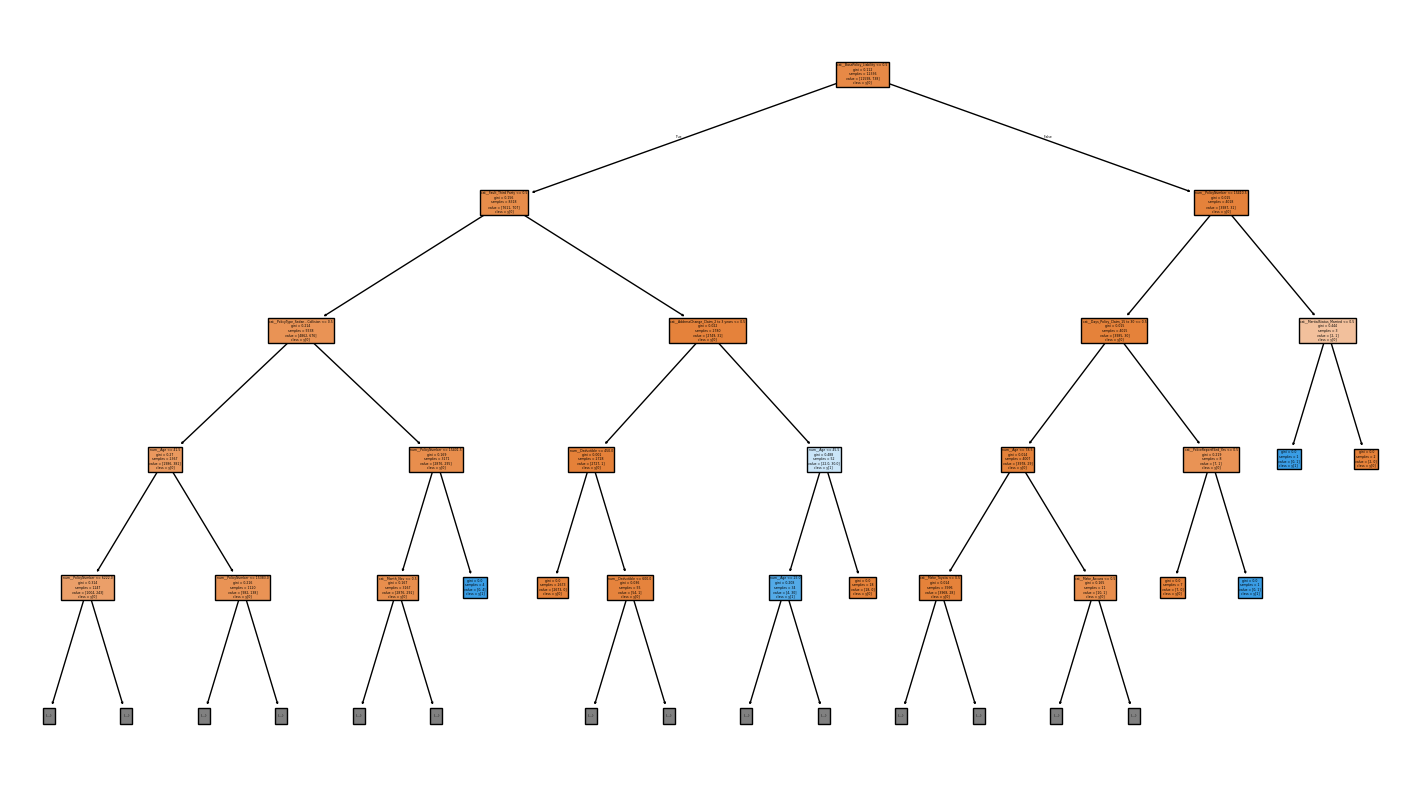

In [90]:
# -------------------------------------------
# Optional: plot tree (needs matplotlib)
# -------------------------------------------
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 10))
plot_tree(clf, feature_names=feature_names, class_names=True, filled=True, max_depth=4)
plt.show()

In [103]:
# -------------------------------------------
# 7) Feature Importance (FI) from the best Decision Tree
# (use clear names so it won't clash with XGB variables)
# -------------------------------------------
import pandas as pd

dt_preproc = dt_best.named_steps["preprocessor"]
dt_clf = dt_best.named_steps["classifier"]

# Get feature names after preprocessing
try:
    dt_feature_names = dt_preproc.get_feature_names_out()
except Exception:
    dt_feature_names = [f"f{i}" for i in range(dt_clf.n_features_in_)]

# DecisionTreeClassifier has feature_importances_
dt_fi = pd.Series(dt_clf.feature_importances_, index=dt_feature_names)

# Sort high to low, and drop zeros for readability (optional)
dt_fi_sorted = dt_fi.sort_values(ascending=False)
dt_fi_nonzero = dt_fi_sorted[dt_fi_sorted > 0]

print("\nTop Feature Importances (Decision Tree):")
print(dt_fi_nonzero.head(20))


Top Feature Importances (Decision Tree):
num__PolicyNumber                        0.217989
num__Age                                 0.086703
cat__Fault_Third Party                   0.063008
cat__AddressChange_Claim_2 to 3 years    0.046938
cat__BasePolicy_Liability                0.044776
num__WeekOfMonth                         0.030636
num__RepNumber                           0.024223
num__DriverRating                        0.020523
cat__MonthClaimed_Oct                    0.018199
cat__PolicyType_Sedan - Collision        0.017308
cat__AgeOfVehicle_6 years                0.014042
num__WeekOfMonthClaimed                  0.013469
cat__DayOfWeekClaimed_Tuesday            0.012030
cat__NumberOfSuppliments_none            0.010832
cat__MonthClaimed_Jan                    0.010799
cat__Make_Accura                         0.010762
cat__VehiclePrice_20000 to 29000         0.010740
cat__Month_Jan                           0.009839
cat__AgeOfPolicyHolder_31 to 35          0.009676
cat__Mon

In [104]:
# ------------------------------------
# 0. NOTE: This block takes quite a while to run, do it before moving onto explanation of code
# ------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For classification, prefer stratified splits so class balance is similar in each split
cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# -------------------------------------------
# 1. Create pipelines for both models
# -------------------------------------------

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"  # sensible default for binary classification
    ))
])

# -------------------------------------------
# 2. Define parameter grids
# Keep them small for speed and simplicity
# -------------------------------------------

param_grid_rf = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [5, 10],
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

param_grid_xgb = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [2, 4, 6],
    "classifier__eval_metric": ["logloss", "auc"]
}

# -------------------------------------------
# 3. Create GridSearchCV objects
# -------------------------------------------
#make scorer mcc
from sklearn.metrics import make_scorer, matthews_corrcoef


gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4. Fit both models
# (Students can run one at a time if needed)
# -------------------------------------------

gs_rf.fit(X_train, y_train)
print("Random Forest grid search complete.")

gs_xgb.fit(X_train, y_train)
print("XGBoost grid search complete.")

# -------------------------------------------
# 5. Evaluate on test set
# -------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

rf_pred = gs_rf.best_estimator_.predict(X_test)
xgb_pred = gs_xgb.best_estimator_.predict(X_test)

print("\nRF MCC:", matthews_corrcoef(y_test, rf_pred))
print("Best RF Params:", gs_rf.best_params_)
print("\nRF Classification Report:\n", classification_report(y_test, rf_pred))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nXGB MCC:", matthews_corrcoef(y_test, xgb_pred))
print("Best XGB Params:", gs_xgb.best_params_)
print("\nXGB Classification Report:\n", classification_report(y_test, xgb_pred))
print("XGB Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Random Forest grid search complete.
Fitting 10 folds for each of 12 candidates, totalling 120 fits
XGBoost grid search complete.

RF MCC: 0.07129375364786289
Best RF Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__n_estimators': 50}

RF Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.97      0.50      0.49      3084
weighted avg       0.94      0.94      0.91      3084

RF Confusion Matrix:
 [[2899    0]
 [ 184    1]]

XGB MCC: 0.6031665840989223
Best XGB Params: {'classifier__eval_metric': 'logloss', 'classifier__max_depth': 4, 'classifier__n_estimators': 200}

XGB Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.

In [105]:
# -------------------------------------------
# 6) Feature Importance (FI) for the best XGBoost model (from GridSearch)
# (use clear names so it won't clash with DT variables)
# -------------------------------------------
import numpy as np
import pandas as pd

xgb_best_pipe = gs_xgb.best_estimator_
xgb_preproc = xgb_best_pipe.named_steps["preprocessor"]
xgb_clf = xgb_best_pipe.named_steps["classifier"]

# Feature names after preprocessing
try:
    xgb_feature_names = xgb_preproc.get_feature_names_out()
except Exception:
    xgb_feature_names = np.array([f"f{i}" for i in range(xgb_clf.n_features_in_)], dtype=object)

# XGBoost importance types:
# - "gain": average gain of splits using the feature (closest to tree FI conceptually)
# - "weight": number of times feature is used in splits
# - "cover": average coverage (samples affected) of splits using the feature
xgb_importance_type = "gain"

# Get raw importances keyed by "f0", "f1", ...
xgb_raw = xgb_clf.get_booster().get_score(importance_type=xgb_importance_type)

# Convert to aligned Series for all features (missing -> 0)
xgb_fi = pd.Series(0.0, index=xgb_feature_names)
for k, v in xgb_raw.items():
    # k looks like "f12" -> index 12
    idx = int(k[1:])
    if idx < len(xgb_feature_names):
        xgb_fi.iloc[idx] = float(v)

xgb_fi_sorted = xgb_fi.sort_values(ascending=False)

print(f"\nTop XGBoost Feature Importances (importance_type='{xgb_importance_type}'):")
print(xgb_fi_sorted.head(20))

print("\nNotes:")
print("- XGBoost FI depends on importance_type (gain/weight/cover).")
print("- These values are not on the same scale as Decision Tree FI (Decision Tree sums to 1).")
print("- Adding FI numbers across different runs/folds does not make sense.")
print("- Comparing FI across different model families is not directly meaningful.")

# Optional: show other importance types for comparison (top 10 each)
for t in ["weight", "cover"]:
    xgb_raw_t = xgb_clf.get_booster().get_score(importance_type=t)

    xgb_fi_t = pd.Series(0.0, index=xgb_feature_names)
    for k, v in xgb_raw_t.items():
        idx = int(k[1:])
        if idx < len(xgb_feature_names):
            xgb_fi_t.iloc[idx] = float(v)

    print(f"\nTop XGBoost FI (importance_type='{t}'):")
    print(xgb_fi_t.sort_values(ascending=False).head(10))


Top XGBoost Feature Importances (importance_type='gain'):
cat__Fault_Policy Holder                  32.038872
cat__BasePolicy_Liability                 27.899673
cat__AddressChange_Claim_2 to 3 years     17.242857
cat__PolicyType_Sedan - Collision         10.442424
cat__Month_Dec                             9.057192
cat__MonthClaimed_May                      8.694798
cat__Month_Jan                             8.277553
cat__Days_Policy_Accident_more than 30     6.788987
cat__MonthClaimed_Jan                      6.573642
cat__Month_Feb                             5.354228
cat__MonthClaimed_Sep                      5.302149
num__PolicyNumber                          5.216366
cat__Month_Sep                             4.830886
cat__MonthClaimed_Nov                      4.559146
cat__Month_Mar                             4.550285
cat__Make_VW                               4.371064
cat__Month_Oct                             4.177876
cat__MonthClaimed_Aug                      4.020991
cat__

In [106]:
# -------------------------------------------
# 8) Permutation Feature Importance (pFI)
# What mattered most to prediction accuracy
# -------------------------------------------

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import matthews_corrcoef, make_scorer

# Use MCC to stay consistent with model selection
mcc_scorer = make_scorer(matthews_corrcoef)

# IMPORTANT:
# - pFI must be computed on held-out data
# - the model must already be trained
# - we do NOT refit the model here

# Compute permutation importance on the TEST set
pfi = permutation_importance(
    estimator=dt_best,
    X=X_test,
    y=y_test,
    scoring=mcc_scorer,
    n_repeats=10,          # repeat permutations for stability
    random_state=42,
    n_jobs=-1
)

# Mean drop in score across repeats
pfi_mean = pd.Series(
    pfi.importances_mean,
    index=X_test.columns
)

# Optional: variability across repeats (for teaching discussion)
pfi_std = pd.Series(
    pfi.importances_std,
    index=X_test.columns
)

# Sort by importance (largest performance drop first)
pfi_sorted = pfi_mean.sort_values(ascending=False)

print("\nTop Permutation Feature Importances (Decision Tree, MCC drop):")
print(pfi_sorted.head(20))


Top Permutation Feature Importances (Decision Tree, MCC drop):
PolicyNumber           0.104351
Fault                  0.103327
Month                  0.085370
BasePolicy             0.074953
AddressChange_Claim    0.040635
PolicyType             0.032525
MonthClaimed           0.013281
AgeOfVehicle           0.011152
Deductible             0.009012
VehicleCategory        0.004485
Sex                    0.004075
RepNumber              0.003289
PastNumberOfClaims     0.003193
Age                    0.001968
NumberOfCars           0.001307
NumberOfSuppliments    0.000881
Make                   0.000850
Days_Policy_Claim      0.000577
WitnessPresent         0.000304
PoliceReportFiled      0.000304
dtype: float64


In [121]:
# Build comparison table
dt_fi_vs_pfi = pd.DataFrame({
    "DT_FI (split-based)": dt_fi,
    "DT_pFI (MCC_drop)": pfi_mean
})

# Sort by pFI (what matters most to accuracy)
dt_fi_vs_pfi_sorted = dt_fi_vs_pfi.sort_values(
    by="DT_pFI (MCC_drop)",
    ascending=False
)

print("\nDecision Tree: FI vs Permutation FI (sorted by pFI):")
print(dt_fi_vs_pfi_sorted.head(20))


Decision Tree: FI vs Permutation FI (sorted by pFI):
                     DT_FI (split-based)  DT_pFI (MCC_drop)
PolicyNumber                         NaN           0.104351
Fault                                NaN           0.103327
Month                                NaN           0.085370
BasePolicy                           NaN           0.074953
AddressChange_Claim                  NaN           0.040635
PolicyType                           NaN           0.032525
MonthClaimed                         NaN           0.013281
AgeOfVehicle                         NaN           0.011152
Deductible                           NaN           0.009012
VehicleCategory                      NaN           0.004485
Sex                                  NaN           0.004075
RepNumber                            NaN           0.003289
PastNumberOfClaims                   NaN           0.003193
Age                                  NaN           0.001968
NumberOfCars                         NaN      

Sharp

In [122]:
# Pipelines: preprocessor + classifier
dt_best_pipe  = dt_best
xgb_best_pipe = gs_xgb.best_estimator_

In [123]:
import shap

# Get preprocessors and final estimators
dt_pre  = dt_best_pipe.named_steps["preprocessor"]
dt_clf  = dt_best_pipe.named_steps["classifier"]

xgb_pre = xgb_best_pipe.named_steps["preprocessor"]
xgb_clf = xgb_best_pipe.named_steps["classifier"]

def safe_feature_names(preprocessor):
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        return None

dt_feature_names  = safe_feature_names(dt_pre)
xgb_feature_names = safe_feature_names(xgb_pre)

print("DT feature names available:", dt_feature_names is not None)
print("XGB feature names available:", xgb_feature_names is not None)

DT feature names available: True
XGB feature names available: True


In [124]:
RANDOM_STATE = 42
BG_N = 300   # keep small for speed + stability

X_train_df = (
    X_train.copy()
    if isinstance(X_train, pd.DataFrame)
    else pd.DataFrame(X_train)
)
y_train_ser = (
    y_train.copy()
    if isinstance(y_train, (pd.Series, pd.DataFrame))
    else pd.Series(y_train, name="y")
)

X_bg = X_train_df.sample(
    n=min(BG_N, len(X_train_df)),
    random_state=RANDOM_STATE
)

In [125]:
# Transform background and test sets
X_bg_dt  = dt_pre.transform(X_bg)
X_bg_xgb = xgb_pre.transform(X_bg)

X_test_dt  = dt_pre.transform(X_test)
X_test_xgb = xgb_pre.transform(X_test)

print("Shapes:")
print("X_bg_dt  :", X_bg_dt.shape)
print("X_test_dt:", X_test_dt.shape)

Shapes:
X_bg_dt  : (300, 148)
X_test_dt: (3084, 148)


Global SHAP: summary plots (beeswarm + bar)
How to read beeswarm plots:

Each dot is one sample
x-axis is SHAP value
negative: pushes towards class 0
positive: pushes towards class 1
colour shows feature value (high vs low)
Bar plot is mean absolute SHAP (global importance, but direction removed).

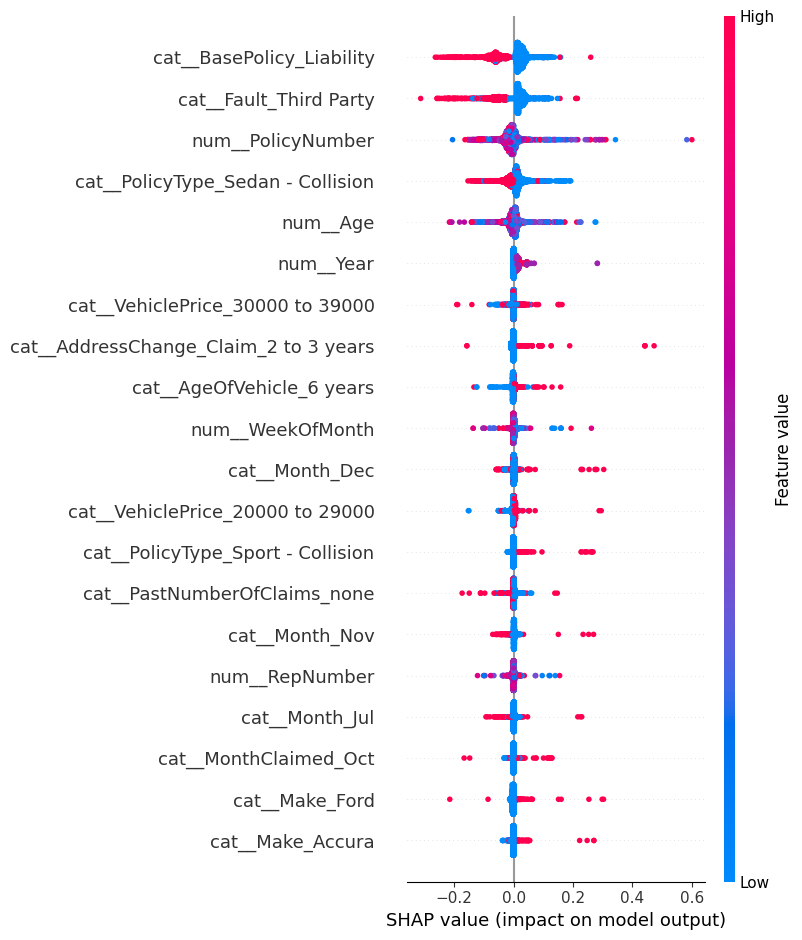

<Figure size 640x480 with 0 Axes>

In [130]:
import shap
from matplotlib import pyplot as plt
import numpy as np

# Convert sparse matrix to dense if needed
if hasattr(X_test_dt, "toarray"):
    X_test_dt_dense = X_test_dt.toarray()
else:
    X_test_dt_dense = X_test_dt  # already dense

# Ensure it's numeric
X_test_dt_dense = X_test_dt_dense.astype(float)

# Create SHAP explainer
expl_dt = shap.TreeExplainer(dt_clf)
shap_dt = expl_dt.shap_values(X_test_dt_dense)

# Binary class
if isinstance(shap_dt, list):
    shap_dt_c1 = shap_dt[1]
else:
    shap_dt_c1 = shap_dt[:, :, 1]

# Features actually used in the tree
used = np.where(dt_clf.feature_importances_ > 0)[0]

X_test_used = X_test_dt_dense[:, used]
names_used = [dt_feature_names[i] for i in used]

# SHAP beeswarm plot
shap.summary_plot(
    shap_dt_c1[:, used],
    X_test_used,
    feature_names=names_used,
    show=True
)
plt.tight_layout()
plt.show()

In [131]:
# XGBoost
expl_xgb = shap.TreeExplainer(xgb_clf)
shap_xgb = expl_xgb.shap_values(X_test_xgb)

if isinstance(shap_xgb, list) and len(shap_xgb) == 2:
    shap_xgb_c1 = shap_xgb[1]
else:
    shap_xgb_c1 = shap_xgb

print("XGB SHAP shape (class 1):", np.array(shap_xgb_c1).shape)

XGB SHAP shape (class 1): (3084, 148)


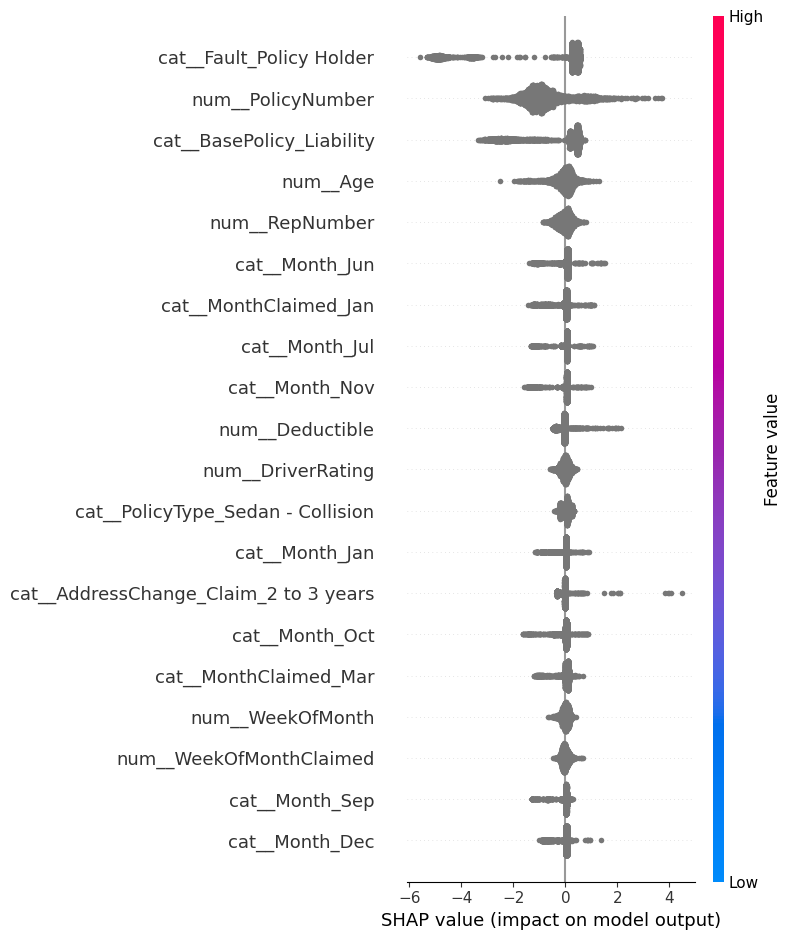

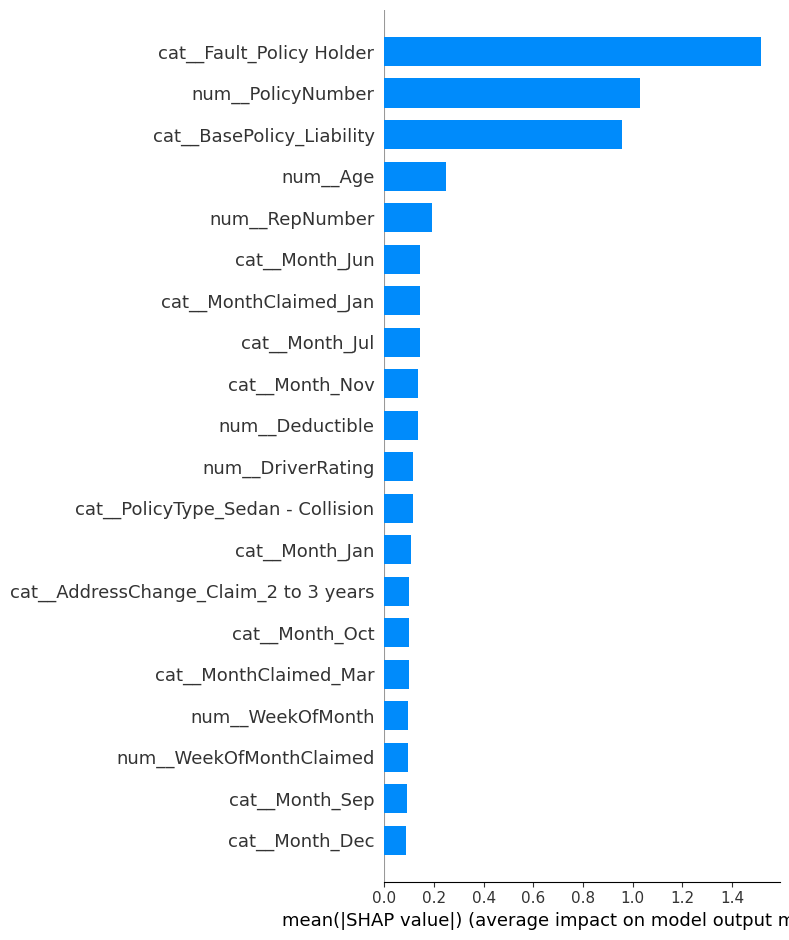

In [132]:
# XGB beeswarm
shap.summary_plot(
    shap_xgb_c1,
    X_test_xgb,
    feature_names=xgb_feature_names,
    show=False
)
plt.tight_layout()
plt.show()

# XGB bar (mean |SHAP|)
shap.summary_plot(
    shap_xgb_c1,
    X_test_xgb,
    feature_names=xgb_feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()

Why SHAP Beeswarm is Better (and Different) from FI and pFI Bar Plots
When you compare Feature Importance (FI), Permutation Feature Importance (pFI), and the SHAP beeswarm plot, you are looking at three different ways of answering:

“Which features matter most in this model?”

But doctors often need a more useful question:

“For this feature, should I be worried about a high value or a low value?”

Standard Definitions (What Each Plot Means)
Method	What it tells you (simple meaning)	Output Type
FI (Built-in importance)	Which features the model uses most during training	One bar per feature
pFI (Permutation importance)	Which features reduce accuracy when you shuffle them	One bar per feature
SHAP Beeswarm	How features push predictions higher or lower in the data	Many dots per feature
1. FI and pFI Only Tell You “worst perimeter is Important”
FI and pFI bar plots might show:

worst perimeter is one of the top important features.

But doctors still do not know:

Does a high worst perimeter increase cancer risk?
Does a low worst perimeter increase cancer risk?
Which direction is the warning sign?
Bar plots cannot answer this.

2. Beeswarm Shows Whether worst perimeter Pushes Risk Up or Down
The SHAP beeswarm plot shows direction:

Left side → feature pushes prediction lower
Right side → feature pushes prediction higher
So doctors can understand:

“Does worst perimeter push the model towards benign or malignant?”

Example:

If lower worst perimeter values push prediction towards malignant, then low values are the worrying sign.
FI and pFI cannot show this direction. Beeswarm can.

3. Beeswarm Shows the Pattern Across the Dataset
FI and pFI give only one bar:

worst perimeter → one importance score
But beeswarm shows many dots:

worst perimeter → many patients in the dataset
This helps doctors see:

Low worst perimeter values often push towards malignant
High worst perimeter values often push towards benign
So beeswarm answers:

“Is this pattern happening across the dataset?”

4. Beeswarm Uses Colour to Show High vs Low worst perimeter
In the beeswarm plot:

Red = high worst perimeter values
Blue = low worst perimeter values
This makes it very clear:

If blue dots are mostly on the right, then low worst perimeter increases malignant risk
Doctors can directly see:

“Low values are more alarming in this model.”

FI and pFI cannot show this.

5. Beeswarm Can Show When worst perimeter is Not Always Simple
Sometimes you may see:

Blue dots on both left and right sides
This means:

Low worst perimeter is often a warning sign, but not always.

Doctors should not rely on one feature alone.

Bar plots hide this kind of detail.

Known Caveats and Exceptions
Method	Main limitation
FI	Can be biased towards features with many split points
pFI	Can look weak when features are strongly related
SHAP	Takes more time to compute and needs careful reading
Important note:

If another feature is very similar to worst perimeter, SHAP may split the effect.
Summary: Why Beeswarm is Often Better
SHAP beeswarm is usually preferred because it shows:

✅ worst perimeter matters

✅ whether it pushes prediction towards malignant or benign

✅ whether high (red) or low (blue) values are the warning sign

✅ clearer patterns across the dataset

So instead of only saying:

“worst perimeter is important”

Beeswarm explains:

“worst perimeter is important, and in this model, lower values (blue) push predictions towards malignant, so doctors should pay attention to low values.”

In [133]:
xgb_feature_names[:]

['num__WeekOfMonth',
 'num__WeekOfMonthClaimed',
 'num__Age',
 'num__PolicyNumber',
 'num__RepNumber',
 'num__Deductible',
 'num__DriverRating',
 'num__Year',
 'cat__Month_Apr',
 'cat__Month_Aug',
 'cat__Month_Dec',
 'cat__Month_Feb',
 'cat__Month_Jan',
 'cat__Month_Jul',
 'cat__Month_Jun',
 'cat__Month_Mar',
 'cat__Month_May',
 'cat__Month_Nov',
 'cat__Month_Oct',
 'cat__Month_Sep',
 'cat__DayOfWeek_Friday',
 'cat__DayOfWeek_Monday',
 'cat__DayOfWeek_Saturday',
 'cat__DayOfWeek_Sunday',
 'cat__DayOfWeek_Thursday',
 'cat__DayOfWeek_Tuesday',
 'cat__DayOfWeek_Wednesday',
 'cat__Make_Accura',
 'cat__Make_BMW',
 'cat__Make_Chevrolet',
 'cat__Make_Dodge',
 'cat__Make_Ferrari',
 'cat__Make_Ford',
 'cat__Make_Honda',
 'cat__Make_Jaguar',
 'cat__Make_Lexus',
 'cat__Make_Mazda',
 'cat__Make_Mecedes',
 'cat__Make_Mercury',
 'cat__Make_Nisson',
 'cat__Make_Pontiac',
 'cat__Make_Porche',
 'cat__Make_Saab',
 'cat__Make_Saturn',
 'cat__Make_Toyota',
 'cat__Make_VW',
 'cat__AccidentArea_Rural',
 'ca

In [134]:
import numpy as np

# Mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_xgb_c1).mean(axis=0)

# Sort feature indices by impact (descending)
order = np.argsort(mean_abs_shap)[::-1]

# Sorted feature names (most impactful first)
xgb_feature_names_sorted = [xgb_feature_names[i] for i in order]

# Optional: preview top features
print("Top SHAP features:")
for name, val in zip(xgb_feature_names_sorted[:10], mean_abs_shap[order][:10]):
    print(f"{name:30s}  mean|SHAP| = {val:.4f}")

Top SHAP features:
cat__Fault_Policy Holder        mean|SHAP| = 1.5168
num__PolicyNumber               mean|SHAP| = 1.0275
cat__BasePolicy_Liability       mean|SHAP| = 0.9589
num__Age                        mean|SHAP| = 0.2486
num__RepNumber                  mean|SHAP| = 0.1913
cat__Month_Jun                  mean|SHAP| = 0.1449
cat__MonthClaimed_Jan           mean|SHAP| = 0.1438
cat__Month_Jul                  mean|SHAP| = 0.1430
cat__Month_Nov                  mean|SHAP| = 0.1378
num__Deductible                 mean|SHAP| = 0.1356


Using feature: cat__Fault_Policy Holder


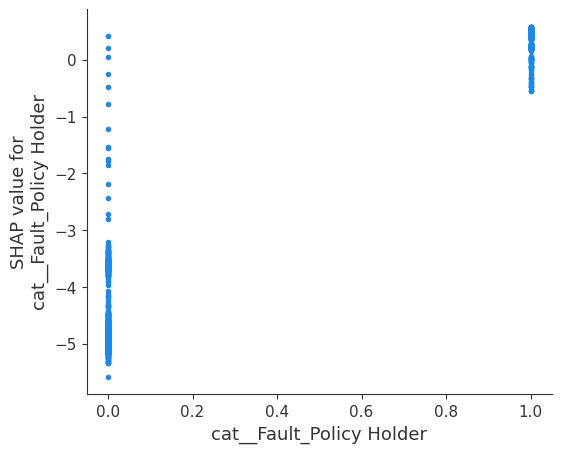

<Figure size 640x480 with 0 Axes>

In [136]:
# -------------------------------
# 1) Pick a feature by name
# -------------------------------
feature_name = xgb_feature_names_sorted[0]  # e.g., from SHAP bar plot
print("Using feature:", feature_name)

# -------------------------------
# 2) Ensure X_test_xgb is numeric
# -------------------------------
if hasattr(X_test_xgb, "toarray"):  # sparse matrix
    X_test_dense = X_test_xgb.toarray()
elif isinstance(X_test_xgb, pd.DataFrame):
    X_test_dense = X_test_xgb.values
else:  # already NumPy array
    X_test_dense = X_test_xgb

X_test_dense = X_test_dense.astype(float)

# -------------------------------
# 3) Ensure shap values are correct
# -------------------------------
# shap_xgb_c1 should be class 1 (binary)
if isinstance(shap_xgb_c1, list):
    shap_vals = shap_xgb_c1[1]  # pick class 1
else:
    shap_vals = shap_xgb_c1

# -------------------------------
# 4) Create dependence plot
# -------------------------------
shap.dependence_plot(
    feature_name,
    shap_vals,
    X_test_dense,
    feature_names=xgb_feature_names,  # must match columns in X_test_dense
    interaction_index=None,  # removes color dimension
    show=True
)

plt.tight_layout()
plt.show()

How to Read This SHAP Dependence Plot (worst perimeter)
This plot helps doctors understand how worst perimeter affects the model prediction.

A doctor’s real question is:

“At what value should I start to be more careful?”

1) X-axis: Tumour perimeter value
The bottom axis shows the actual value of:

num__worst perimeter

Left side = smaller perimeter
Right side = larger perimeter
2) Y-axis: Does the model become more worried or less worried?
The SHAP value shows the impact:

SHAP above 0 → pushes prediction towards malignant
SHAP below 0 → pushes prediction towards benign
So this tells doctors:

“Does this perimeter value increase cancer risk or reduce it?”

3) Actionable pattern in this plot
When perimeter is small (around 60–100)
Most points are above 0.

This means:

Small worst perimeter values push the model towards malignant.

So low values are a warning sign.

When perimeter is larger (above ~110)
Most points are below 0.

This means:

Larger worst perimeter values push the model towards benign.

So the model is less worried.

4) The overlap region (around 100–110)
Notice that around 100 to 110, points start to mix.

This means:

This is a transition zone where the model is not perfectly certain.

Some cases still look risky even near 100.

5) Healthcare recommendation (false negatives are costly)
In healthcare:

A false negative (missing a malignant case) is more harmful to patients
Doctors prefer to be more cautious
So instead of using a cut-off like 100, it may be safer to recommend:

Doctors pay closer attention when worst perimeter is below 110

This reduces the chance of missing a risky patient in the overlap region.

Key takeaway
This plot gives an actionable insight:

worst perimeter is not just important, but values below about 110 should raise more concern, especially when patient safety is the priority.

Plotting dependence for feature: cat__Fault_Policy Holder


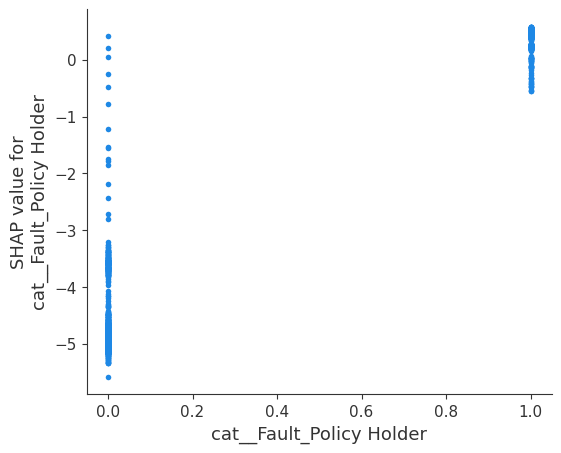

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: num__PolicyNumber


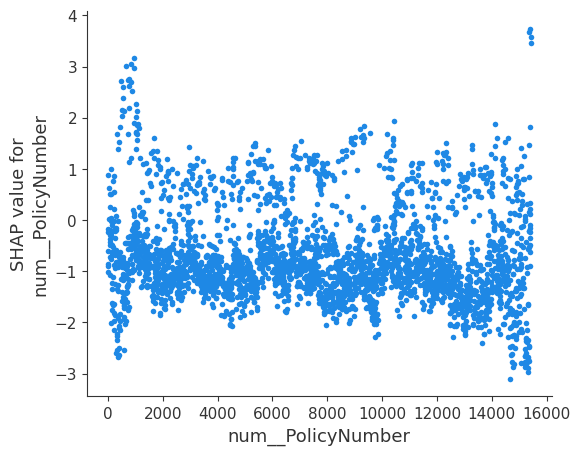

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: cat__BasePolicy_Liability


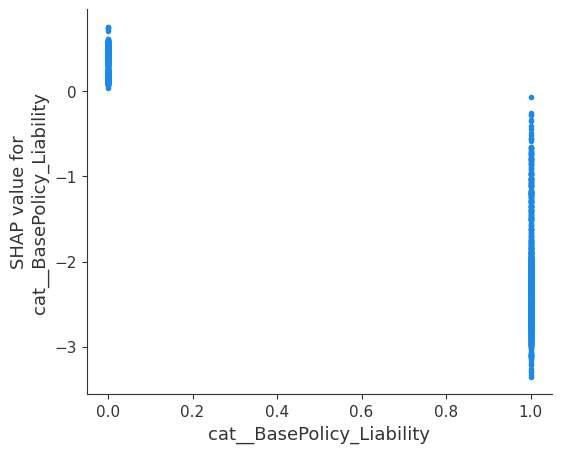

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: num__Age


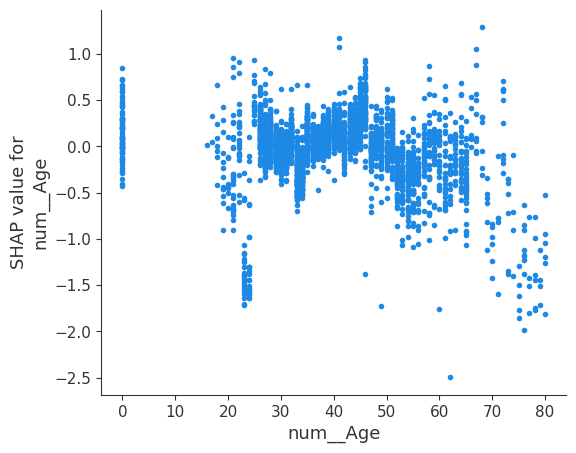

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: num__RepNumber


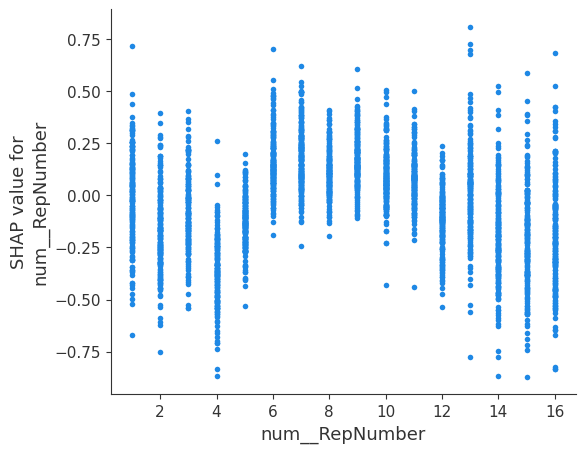

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: cat__Month_Jun


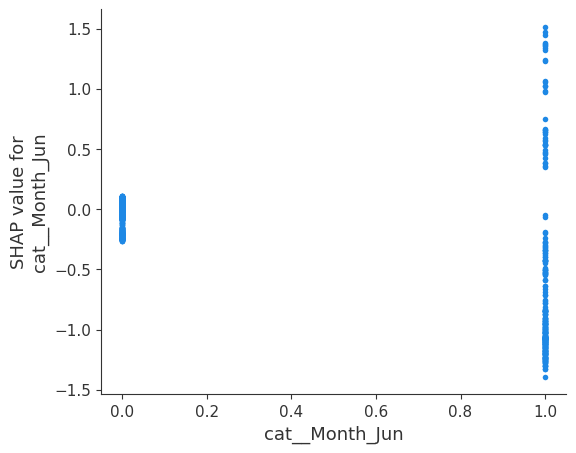

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: cat__MonthClaimed_Jan


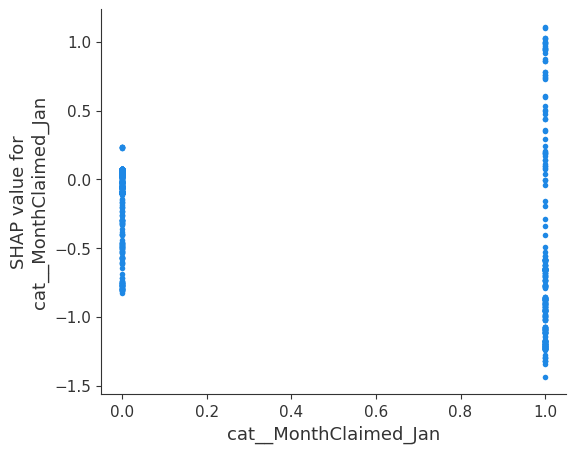

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: cat__Month_Jul


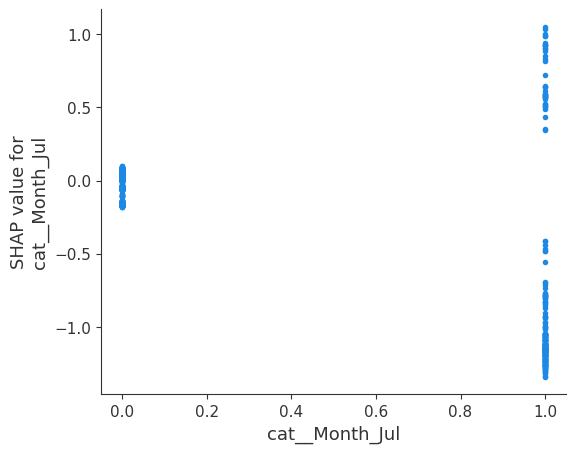

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: cat__Month_Nov


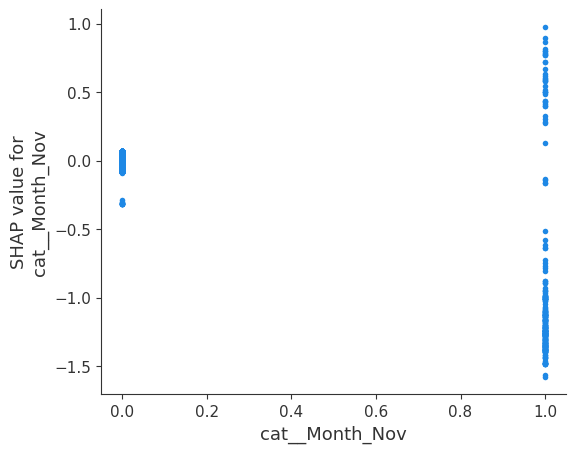

<Figure size 640x480 with 0 Axes>

Plotting dependence for feature: num__Deductible


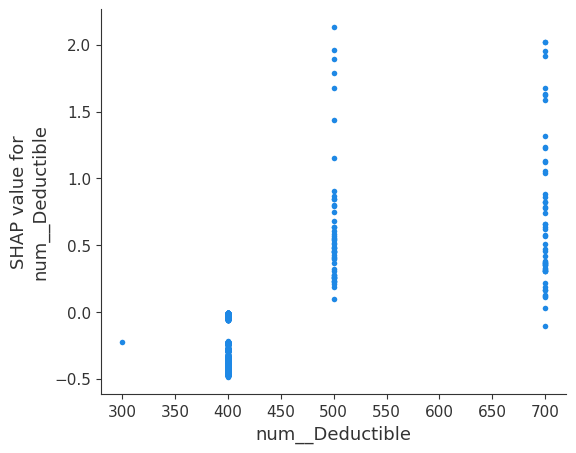

<Figure size 640x480 with 0 Axes>

In [138]:
# -------------------------------
# Ensure X_test_xgb is numeric & dense
# -------------------------------
if hasattr(X_test_xgb, "toarray"):  # sparse matrix
    X_test_dense = X_test_xgb.toarray()
elif isinstance(X_test_xgb, pd.DataFrame):
    X_test_dense = X_test_xgb.values
else:
    X_test_dense = X_test_xgb

X_test_dense = X_test_dense.astype(float)

# -------------------------------
# Ensure SHAP values are class 1 (binary classification)
# -------------------------------
if isinstance(shap_xgb_c1, list):
    shap_vals = shap_xgb_c1[1]  # class 1
else:
    shap_vals = shap_xgb_c1

# -------------------------------
# Loop over top 10 features
# -------------------------------
for feature_name in xgb_feature_names_sorted[:10]:
    print("Plotting dependence for feature:", feature_name)

    shap.dependence_plot(
        feature_name,
        shap_vals,
        X_test_dense,
        feature_names=xgb_feature_names,
        interaction_index=None,  # remove color dimension
        show=True
    )
    plt.tight_layout()
    plt.show()

Local explanations: waterfall plot (one case)
Why this matters: This is the most “stakeholder friendly” explanation.

You will explain one test case:

baseline (expected value)
top positive contributors
top negative contributors
final model output
For multiclass, you must decide which class you are explaining.

SHAP vs FI vs pFI: quick comparison for action
What you are comparing
pFI answers: “What hurts MCC if this column becomes unreliable?”
SHAP answers: “What pushes predictions most, and in which direction?”
Important mismatch:
pFI is computed on raw columns. SHAP often works on expanded columns (after one-hot).

shap_for_class shape: (3084, 148)
baseline (base_for_class): -3.18938

Chosen true target_class: 1
Chosen feature: cat__Fault_Policy Holder
Row selection mode: max_pos
Selected row index i (within X_test): 1078
Feature SHAP at i: 0.578419

Top contributors for this case (by |SHAP|):
- cat__Fault_Policy Holder       SHAP= 0.5784 (pushes UP)
- num__PolicyNumber              SHAP= 0.5449 (pushes UP)
- num__RepNumber                 SHAP=-0.5266 (pushes DOWN)
- cat__BasePolicy_Liability      SHAP= 0.5183 (pushes UP)
- cat__MonthClaimed_Sep          SHAP= 0.4948 (pushes UP)
- cat__PolicyType_Sport - Collision SHAP= 0.3707 (pushes UP)
- num__Age                       SHAP= 0.3330 (pushes UP)
- cat__PolicyType_Sedan - Collision SHAP= 0.2378 (pushes UP)
- cat__Month_Sep                 SHAP= 0.2222 (pushes UP)
- num__WeekOfMonthClaimed        SHAP=-0.1874 (pushes DOWN)
- cat__DayOfWeekClaimed_Wednesday SHAP=-0.1599 (pushes DOWN)
- num__WeekOfMonth               SHAP= 0.1534 (pushes UP)


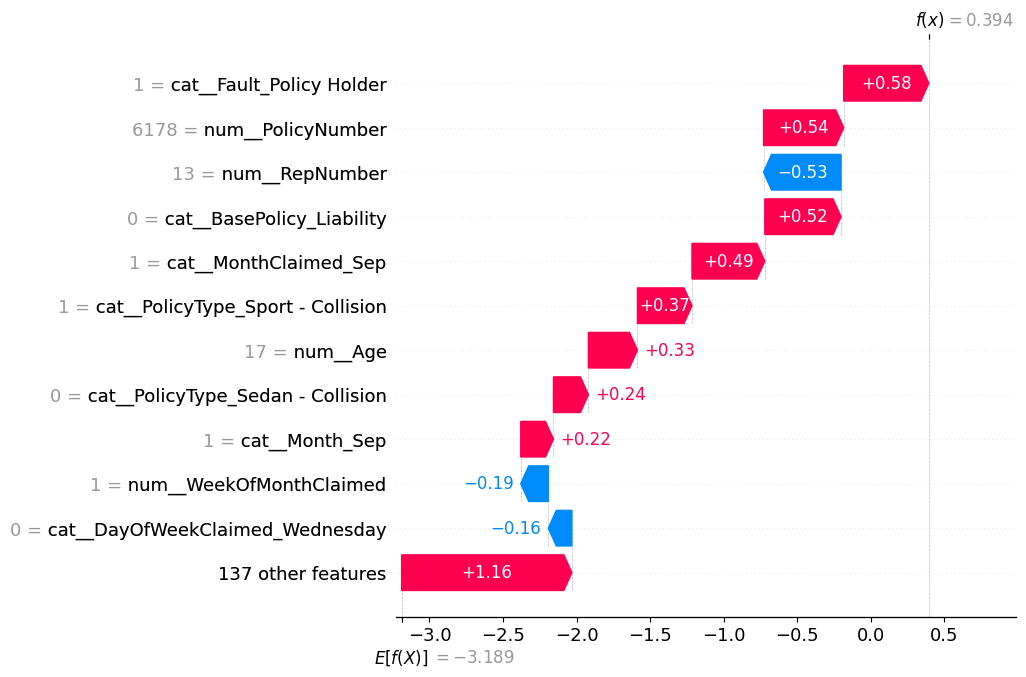

In [144]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Student choices
# ------------------------------------------------------------
target_class = 1                       # choose 0 or 1 (true label group)
feature_name = xgb_feature_names_sorted[0]

# Choose how to pick the "most interesting" row for this feature:
# - "max_pos"  : row where SHAP(feature) is most positive (pushes UP most)
# - "max_neg"  : row where SHAP(feature) is most negative (pushes DOWN most)
# - "max_abs"  : row where |SHAP(feature)| is largest (strongest impact either way)
# - "near_zero": row where SHAP(feature) is closest to 0 (feature has least impact)
pick_mode = "max_pos"                  # change to: "max_neg", "max_abs", "near_zero"


# ------------------------------------------------------------
# Helper: get SHAP matrix for a chosen class (robust to formats)
# ------------------------------------------------------------
def get_shap_matrix_for_class(explainer, X, target_class: int):
    sv = explainer.shap_values(X)

    # Case A: list of arrays, one per class
    if isinstance(sv, list):
        return sv[target_class], explainer.expected_value[target_class]

    sv = np.asarray(sv)

    # Case B: 3D array (n_samples, n_features, n_classes)
    if sv.ndim == 3:
        base = explainer.expected_value
        base_for_class = base[target_class] if isinstance(base, (list, np.ndarray)) else base
        return sv[:, :, target_class], base_for_class

    # Case C: 2D array (n_samples, n_features) for binary
    base = explainer.expected_value
    base_for_class = base if not isinstance(base, (list, np.ndarray)) else base[0]
    return sv, base_for_class


# ------------------------------------------------------------
# 1) Get SHAP for the chosen class (or single-output fallback)
# ------------------------------------------------------------
shap_for_class, base_for_class = get_shap_matrix_for_class(expl_xgb, X_test_xgb, target_class)

print("shap_for_class shape:", np.asarray(shap_for_class).shape)
print("baseline (base_for_class):", base_for_class)


# ------------------------------------------------------------
# 2) Filter row indices by TRUE label group
# ------------------------------------------------------------
y_test_arr = np.asarray(y_test)
class_idx = np.where(y_test_arr == target_class)[0]
assert len(class_idx) > 0, f"No rows found in y_test for target_class={target_class}"


# ------------------------------------------------------------
# 3) Choose row based on pick_mode for the selected feature
# ------------------------------------------------------------
feat_j = xgb_feature_names.index(feature_name)

shap_vals_feat_in_class = shap_for_class[class_idx, feat_j]

if pick_mode == "max_pos":
    best_pos_in_class = int(np.argmax(shap_vals_feat_in_class))
elif pick_mode == "max_neg":
    best_pos_in_class = int(np.argmin(shap_vals_feat_in_class))
elif pick_mode == "max_abs":
    best_pos_in_class = int(np.argmax(np.abs(shap_vals_feat_in_class)))
elif pick_mode == "near_zero":
    best_pos_in_class = int(np.argmin(np.abs(shap_vals_feat_in_class)))
else:
    raise ValueError('pick_mode must be one of: "max_pos", "max_neg", "max_abs", "near_zero"')

i = int(class_idx[best_pos_in_class])  # row index in X_test

print(f"\nChosen true target_class: {target_class}")
print(f"Chosen feature: {feature_name}")
print(f"Row selection mode: {pick_mode}")
print(f"Selected row index i (within X_test): {i}")
print(f"Feature SHAP at i: {shap_for_class[i, feat_j]:.6f}")


# ------------------------------------------------------------
# 4) Waterfall for that row (modified fix)
# ------------------------------------------------------------
# Convert X_test row to 1D dense array
if hasattr(X_test_xgb, "toarray"):        # sparse matrix
    row_data = X_test_xgb[i].toarray().ravel()
elif isinstance(X_test_xgb, pd.DataFrame): # DataFrame
    row_data = X_test_xgb.iloc[i].values
else:                                      # NumPy array
    row_data = X_test_xgb[i]

# Ensure SHAP values are 1D
row_shap = np.asarray(shap_for_class[i]).ravel()

# Build SHAP Explanation object
exp = shap.Explanation(
    values=row_shap,
    base_values=base_for_class,
    data=row_data,
    feature_names=xgb_feature_names
)

# Top contributors (good for students)
vals = exp.values
top_idx = np.argsort(np.abs(vals))[::-1][:12]
print("\nTop contributors for this case (by |SHAP|):")
for k in top_idx:
    direction = "pushes UP" if vals[k] > 0 else "pushes DOWN"
    print(f"- {xgb_feature_names[k]:30s} SHAP={vals[k]: .4f} ({direction})")

# Waterfall plot
shap.plots.waterfall(exp, max_display=12)
plt.show()

In [145]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, matthews_corrcoef

mcc_scorer = make_scorer(matthews_corrcoef)

# pFI on full pipeline (permutes raw columns correctly)
pfi_xgb = permutation_importance(
    estimator=xgb_best_pipe,
    X=X_test,
    y=y_test,
    scoring=mcc_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

pfi_series = pd.Series(pfi_xgb.importances_mean, index=X_test.columns).sort_values(ascending=False)

# SHAP global importance on transformed feature space
shap_global = pd.Series(np.abs(shap_xgb_c1).mean(axis=0), index=xgb_feature_names).sort_values(ascending=False)

print("Top raw-column pFI (what hurts MCC if broken):")
display(pfi_series.head(10))

print("Top transformed-feature SHAP (what pushes predictions most):")
display(shap_global.head(10))

Top raw-column pFI (what hurts MCC if broken):


,0
PolicyNumber,0.517130
Month,0.383801
MonthClaimed,0.230618
Fault,0.212077
BasePolicy,0.141447
AddressChange_Claim,0.036611
WeekOfMonth,0.015837
Age,0.014026
MaritalStatus,0.011400
VehicleCategory,0.009339


Top transformed-feature SHAP (what pushes predictions most):


,0
cat__Fault_Policy Holder,1.516809
num__PolicyNumber,1.027527
cat__BasePolicy_Liability,0.958852
num__Age,0.248612
num__RepNumber,0.191250
cat__Month_Jun,0.144918
cat__MonthClaimed_Jan,0.143791
cat__Month_Jul,0.142983
cat__Month_Nov,0.137759
num__Deductible,0.135589


Decision plot (optional but powerful)
From FI, pFI, and the SHAP bar plot, you saw which predictors are generally important.

In the SHAP beeswarm plot, you saw how each predictor behaves across many cases (some cases pushed up, some pushed down).

Now, you can piece them together to understand how the model gets from the baseline to the final prediction for each case.

For this decision plot, you are looking at many cases at once, so it shows the “paths” of predictions for a small group of samples.

How to read it (on this plot)
Each line = one case (one row).

The line starts near the baseline (around the grey vertical line, about 0).

As you move up the feature list, the prediction is updated step by step.

A big sideways jump at a feature means that feature had a big impact for that case:

jump right → pushes the model output higher
jump left → pushes the model output lower
Where the line ends at the top is the final model output for that case.

What this specific plot is telling you
You can see two clear groups:

Blue lines end far on the left (about −6 to −8): these cases are being pushed strongly towards the lower-output class.
Pink/red lines end far on the right (about +6 to +10): these cases are being pushed strongly towards the higher-output class.
The biggest “separation” happens near the top features, especially:

num__worst perimeter
num__worst texture
num__area error
num__worst concave points
num__worst area
num__worst radius
Those features are doing most of the heavy lifting in moving cases left vs right.

Daily life analogy
Think of it like building your final shopping bill:

you start from a starting total (baseline),
each item (feature) adds or subtracts,
a big price item causes a big jump,
the final total at the end is your final bill (final prediction).
If you tell me which single line is “your case” (e.g., its index in the sample list), I can explain that one path feature-by-feature (which features pushed it right, which pushed it left, and the biggest turning points).

Tip: keep the sample size small for readability.

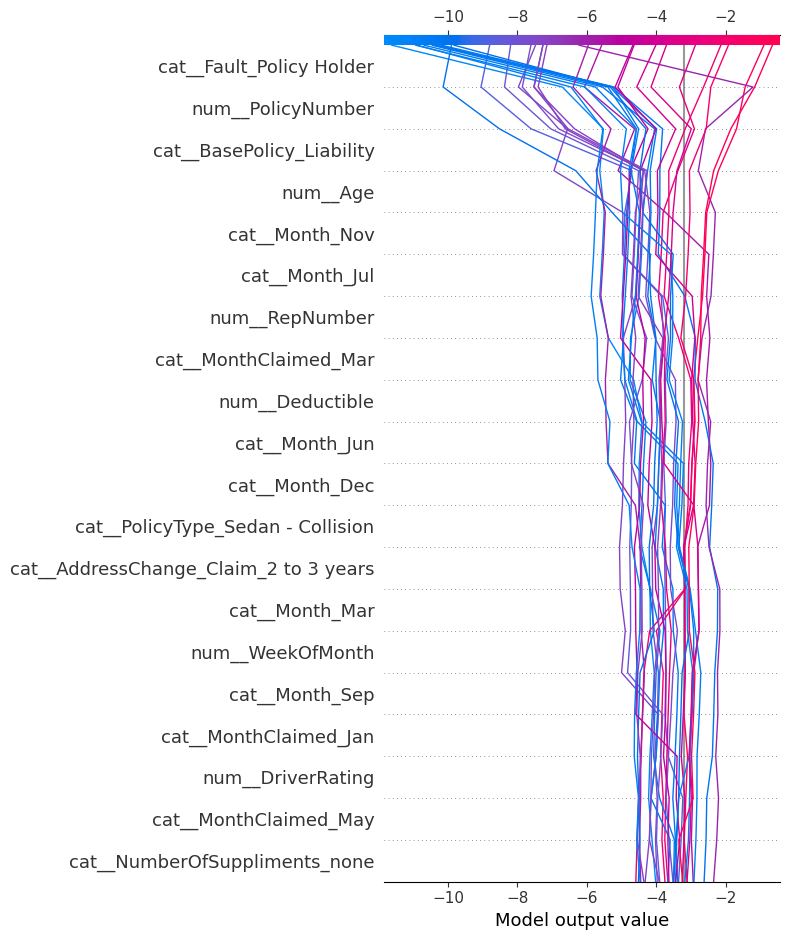

In [146]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# Decision plot for first 30 samples
idx = list(range(30))

# Get a baseline value (expected_value) safely
base_xgb = expl_xgb.expected_value
if isinstance(base_xgb, (list, np.ndarray)):
    # binary or multiclass case
    base_value = base_xgb[target_class] if isinstance(base_xgb, (list, np.ndarray)) else base_xgb
else:
    # scalar baseline
    base_value = base_xgb

shap.decision_plot(
    base_value,
    shap_xgb_c1[idx],
    feature_names=xgb_feature_names,
    show=False
)
plt.tight_layout()
plt.show()

Wrap-up prompts (write-up practice)
Answer briefly in markdown:

Which 3–5 signals are strongest, and do they make domain sense?
For the top 2 signals, what feature values push risk up vs down?
Propose one low-risk action per signal (what would you do differently?)
Which signals might be unstable (correlation, leakage suspicion, proxy features)?
In 2–3 sentences: why is SHAP more decision-ready than FI and pFI?

In [147]:
import numpy as np
import pandas as pd

def summarise_dependence_as_text(
    feature_name: str,
    shap_values_2d,          # shap_xgb_c1: (n_samples, n_features)
    X_2d,                    # X_test_xgb: (n_samples, n_features)
    feature_names: list,
    critical_q=0.90,         # top 10% by |SHAP|
    bins=10                  # for a simple binned trend
):
    j = feature_names.index(feature_name)
    x = np.asarray(X_2d)[:, j]
    s = np.asarray(shap_values_2d)[:, j]

    # 1) Direction (simple correlation as a sign)
    corr = np.corrcoef(x, s)[0, 1]
    direction = "increases" if corr > 0 else "decreases"

    # 2) Turning point (approx where SHAP crosses 0)
    # If it never crosses, report "no crossing"
    sign_change = np.where(np.sign(s[:-1]) != np.sign(s[1:]))[0]
    if len(sign_change) > 0:
        # pick the crossing nearest to s=0 by local min |s|
        k = sign_change[np.argmin(np.abs(s[sign_change]))]
        turning_point = float(np.mean([x[k], x[k+1]]))
        turning_note = f"SHAP crosses 0 around x ≈ {turning_point:.3f}."
    else:
        turning_note = "SHAP does not clearly cross 0 in this sample (mostly one-sided impact)."

    # 3) Critical zone by |SHAP|
    thr = float(np.quantile(np.abs(s), critical_q))
    mask = np.abs(s) >= thr
    if mask.any():
        crit_min = float(np.min(x[mask]))
        crit_max = float(np.max(x[mask]))
        crit_note = (
            f"Critical impact (top {int((1-critical_q)*100)}% by |SHAP|): "
            f"|SHAP| ≥ {thr:.3f} occurs when x is roughly in [{crit_min:.3f}, {crit_max:.3f}]."
        )
    else:
        crit_note = "No points exceed the chosen critical threshold (unexpected)."

    # 4) Typical vs extreme magnitude
    mean_abs = float(np.mean(np.abs(s)))
    max_abs  = float(np.max(np.abs(s)))
    mag_note = f"Average |SHAP| ≈ {mean_abs:.3f}; max |SHAP| ≈ {max_abs:.3f}."

    # 5) Simple binned trend (helps describe ‘when it becomes critical’)
    # bin by feature quantiles for robustness
    qs = np.quantile(x, np.linspace(0, 1, bins + 1))
    # make bins unique (in case of repeated values)
    qs = np.unique(qs)
    if len(qs) >= 3:
        bin_ids = np.digitize(x, qs[1:-1], right=True)
        bin_summary = []
        for b in range(bin_ids.min(), bin_ids.max() + 1):
            xb = x[bin_ids == b]
            sb = s[bin_ids == b]
            if len(xb) == 0:
                continue
            bin_summary.append({
                "x_range": f"[{np.min(xb):.3f}, {np.max(xb):.3f}]",
                "mean_shap": float(np.mean(sb)),
                "mean_abs_shap": float(np.mean(np.abs(sb))),
                "n": int(len(xb))
            })
        bin_df = pd.DataFrame(bin_summary).sort_values("x_range")
        # take the 3 bins with largest mean_abs_shap
        top_bins = bin_df.sort_values("mean_abs_shap", ascending=False).head(3)
        bins_note = "Most impactful value ranges (by mean |SHAP|):\n" + top_bins.to_string(index=False)
    else:
        bins_note = "Binned trend unavailable (feature has too few unique values)."

    # Final text blob (student-friendly, API-friendly)
    text = (
        f"Dependence summary for feature: {feature_name}\n"
        f"- Overall trend: as {feature_name} increases, SHAP contribution generally {direction} "
        f"(corr ≈ {corr:.3f}).\n"
        f"- {turning_note}\n"
        f"- {crit_note}\n"
        f"- {mag_note}\n"
        f"- {bins_note}\n"
        f"Caveat: This is model-driven association, not proof of causation."
    )

    return text

# Example usage
feature_name = xgb_feature_names_sorted[0]
summary_text = summarise_dependence_as_text(
    feature_name=feature_name,
    shap_values_2d=shap_xgb_c1,
    X_2d=X_test_xgb,
    feature_names=xgb_feature_names,
    critical_q=0.90,
    bins=10
)

print(summary_text)

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

In [148]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

def summarise_dependence_as_text(
    feature_name: str,
    shap_values_2d,          # shap_xgb_c1: (n_samples, n_features)
    X_2d,                    # X_test_xgb: (n_samples, n_features)
    feature_names: list,
    critical_q=0.90,
    bins=10
):
    j = feature_names.index(feature_name)

    # -------------------------------------------------
    # FIX: properly convert X_2d to 2D numeric array
    # -------------------------------------------------
    if sp.issparse(X_2d):
        X_array = X_2d.toarray()
    elif isinstance(X_2d, pd.DataFrame):
        X_array = X_2d.values
    else:
        X_array = np.asarray(X_2d)

    shap_array = np.asarray(shap_values_2d)

    # Safe indexing
    x = X_array[:, j]
    s = shap_array[:, j]

    # 1) Direction
    corr = np.corrcoef(x, s)[0, 1]
    direction = "increases" if corr > 0 else "decreases"

    # 2) Turning point
    sign_change = np.where(np.sign(s[:-1]) != np.sign(s[1:]))[0]
    if len(sign_change) > 0:
        k = sign_change[np.argmin(np.abs(s[sign_change]))]
        turning_point = float(np.mean([x[k], x[k+1]]))
        turning_note = f"SHAP crosses 0 around x ≈ {turning_point:.3f}."
    else:
        turning_note = "SHAP does not clearly cross 0 in this sample (mostly one-sided impact)."

    # 3) Critical zone
    thr = float(np.quantile(np.abs(s), critical_q))
    mask = np.abs(s) >= thr
    if mask.any():
        crit_min = float(np.min(x[mask]))
        crit_max = float(np.max(x[mask]))
        crit_note = (
            f"Critical impact (top {int((1-critical_q)*100)}% by |SHAP|): "
            f"|SHAP| ≥ {thr:.3f} occurs when x is roughly in [{crit_min:.3f}, {crit_max:.3f}]."
        )
    else:
        crit_note = "No points exceed the chosen critical threshold (unexpected)."

    # 4) Magnitude
    mean_abs = float(np.mean(np.abs(s)))
    max_abs  = float(np.max(np.abs(s)))
    mag_note = f"Average |SHAP| ≈ {mean_abs:.3f}; max |SHAP| ≈ {max_abs:.3f}."

    # 5) Binned trend
    qs = np.quantile(x, np.linspace(0, 1, bins + 1))
    qs = np.unique(qs)

    if len(qs) >= 3:
        bin_ids = np.digitize(x, qs[1:-1], right=True)
        bin_summary = []

        for b in range(bin_ids.min(), bin_ids.max() + 1):
            xb = x[bin_ids == b]
            sb = s[bin_ids == b]
            if len(xb) == 0:
                continue

            bin_summary.append({
                "x_range": f"[{np.min(xb):.3f}, {np.max(xb):.3f}]",
                "mean_shap": float(np.mean(sb)),
                "mean_abs_shap": float(np.mean(np.abs(sb))),
                "n": int(len(xb))
            })

        bin_df = pd.DataFrame(bin_summary).sort_values("x_range")
        top_bins = bin_df.sort_values("mean_abs_shap", ascending=False).head(3)
        bins_note = "Most impactful value ranges (by mean |SHAP|):\n" + top_bins.to_string(index=False)
    else:
        bins_note = "Binned trend unavailable (feature has too few unique values)."

    text = (
        f"Dependence summary for feature: {feature_name}\n"
        f"- Overall trend: as {feature_name} increases, SHAP contribution generally {direction} "
        f"(corr ≈ {corr:.3f}).\n"
        f"- {turning_note}\n"
        f"- {crit_note}\n"
        f"- {mag_note}\n"
        f"- {bins_note}\n"
        f"Caveat: This is model-driven association, not proof of causation."
    )

    return text

# Example usage
feature_name = xgb_feature_names_sorted[0]
summary_text = summarise_dependence_as_text(
    feature_name=feature_name,
    shap_values_2d=shap_xgb_c1,
    X_2d=X_test_xgb,
    feature_names=xgb_feature_names,
    critical_q=0.90,
    bins=10
)

print(summary_text)

Dependence summary for feature: cat__Fault_Policy Holder
- Overall trend: as cat__Fault_Policy Holder increases, SHAP contribution generally increases (corr ≈ 0.985).
- SHAP crosses 0 around x ≈ 0.500.
- Critical impact (top 9% by |SHAP|): |SHAP| ≥ 4.906 occurs when x is roughly in [0.000, 0.000].
- Average |SHAP| ≈ 1.517; max |SHAP| ≈ 5.583.
- Binned trend unavailable (feature has too few unique values).
Caveat: This is model-driven association, not proof of causation.


In [149]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

def summarise_dependence_as_text(
    feature_name,
    shap_values_2d,
    X_2d,
    feature_names,
    critical_q=0.90,
    bins=10
):
    # Ensure arrays
    if sp.issparse(X_2d):
        X_array = X_2d.toarray()
    elif isinstance(X_2d, pd.DataFrame):
        X_array = X_2d.values
    else:
        X_array = np.asarray(X_2d)

    shap_array = np.asarray(shap_values_2d)

    # Critical alignment check
    if shap_array.shape[1] != X_array.shape[1]:
        raise ValueError("Mismatch: SHAP columns != feature columns")

    if len(feature_names) != X_array.shape[1]:
        raise ValueError("Mismatch: feature_names length != feature columns")

    # Exact column match
    j = feature_names.index(feature_name)

    x = X_array[:, j].astype(float)
    s = shap_array[:, j].astype(float)

    # Remove NaNs safely
    mask_valid = ~np.isnan(x) & ~np.isnan(s)
    x = x[mask_valid]
    s = s[mask_valid]

    # 1️ Direction
    corr = np.corrcoef(x, s)[0, 1]
    direction = "increases" if corr > 0 else "decreases"

    # 2️ Turning point (sorted by x for stability)
    order = np.argsort(x)
    x_sorted = x[order]
    s_sorted = s[order]

    sign_change = np.where(np.sign(s_sorted[:-1]) != np.sign(s_sorted[1:]))[0]
    if len(sign_change) > 0:
        k = sign_change[0]
        turning_point = float(np.mean([x_sorted[k], x_sorted[k+1]]))
        turning_note = f"SHAP crosses 0 around x ≈ {turning_point:.3f}."
    else:
        turning_note = "SHAP does not clearly cross 0 in this sample."

    # 3️ Critical zone
    thr = float(np.quantile(np.abs(s), critical_q))
    mask_crit = np.abs(s) >= thr

    if mask_crit.any():
        crit_min = float(np.min(x[mask_crit]))
        crit_max = float(np.max(x[mask_crit]))
        crit_note = (
            f"Critical impact (top {int((1-critical_q)*100)}% by |SHAP|): "
            f"|SHAP| ≥ {thr:.3f} occurs when x is roughly in "
            f"[{crit_min:.3f}, {crit_max:.3f}]."
        )
    else:
        crit_note = "No critical region identified."

    # 4️ Magnitude
    mean_abs = float(np.mean(np.abs(s)))
    max_abs  = float(np.max(np.abs(s)))

    # 5️ Binning (stable)
    bin_ids = pd.qcut(x, q=bins, duplicates='drop')
    bin_df = (
        pd.DataFrame({"x": x, "s": s, "bin": bin_ids})
        .groupby("bin")
        .agg(
            x_min=("x", "min"),
            x_max=("x", "max"),
            mean_shap=("s", "mean"),
            mean_abs_shap=("s", lambda v: np.mean(np.abs(v))),
            n=("s", "count")
        )
        .reset_index(drop=True)
    )

    top_bins = bin_df.sort_values("mean_abs_shap", ascending=False).head(3)

    bins_note = (
        "Most impactful value ranges (by mean |SHAP|):\n" +
        top_bins.to_string(index=False)
    )

    text = (
        f"Dependence summary for feature: {feature_name}\n"
        f"- Overall trend: as {feature_name} increases, SHAP contribution generally "
        f"{direction} (corr ≈ {corr:.3f}).\n"
        f"- {turning_note}\n"
        f"- {crit_note}\n"
        f"- Average |SHAP| ≈ {mean_abs:.3f}; max |SHAP| ≈ {max_abs:.3f}.\n"
        f"- {bins_note}\n"
        f"Caveat: This is model-driven association, not proof of causation."
    )

    return text

# Example usage
feature_name = xgb_feature_names_sorted[0]
summary_text = summarise_dependence_as_text(
    feature_name=feature_name,
    shap_values_2d=shap_xgb_c1,
    X_2d=X_test_xgb,
    feature_names=xgb_feature_names,
    critical_q=0.90,
    bins=10
)

print(summary_text)

Dependence summary for feature: cat__Fault_Policy Holder
- Overall trend: as cat__Fault_Policy Holder increases, SHAP contribution generally increases (corr ≈ 0.985).
- SHAP crosses 0 around x ≈ 0.000.
- Critical impact (top 9% by |SHAP|): |SHAP| ≥ 4.906 occurs when x is roughly in [0.000, 0.000].
- Average |SHAP| ≈ 1.517; max |SHAP| ≈ 5.583.
- Most impactful value ranges (by mean |SHAP|):
 x_min  x_max  mean_shap  mean_abs_shap    n
   0.0    1.0  -0.946221       1.516807 3084
Caveat: This is model-driven association, not proof of causation.


/tmp/ipython-input-441641188.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")


In [150]:
from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

In [151]:
import numpy as np

TOP_N = 8  #typically 3–5 is ideal for students

mean_abs_shap = np.abs(shap_xgb_c1).mean(axis=0)
order = np.argsort(mean_abs_shap)[::-1]
top_feature_names = [xgb_feature_names[i] for i in order[:TOP_N]]

print("Top features by mean |SHAP|:")
for f in top_feature_names:
    print("-", f)

Top features by mean |SHAP|:
- cat__Fault_Policy Holder
- num__PolicyNumber
- cat__BasePolicy_Liability
- num__Age
- num__RepNumber
- cat__Month_Jun
- cat__MonthClaimed_Jan
- cat__Month_Jul


In [152]:
dependence_summaries = []

for fname in top_feature_names:
    txt = summarise_dependence_as_text(
        feature_name=fname,
        shap_values_2d=shap_xgb_c1,
        X_2d=X_test_xgb,
        feature_names=xgb_feature_names,
        critical_q=0.90,
        bins=10
    )
    dependence_summaries.append(txt)

/tmp/ipython-input-441641188.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")
/tmp/ipython-input-441641188.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")
/tmp/ipython-input-441641188.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")
/tmp/ipython-input-441641188.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a fu

In [ ]:
# payload_text = f"""
# You are supporting decision-making using a trained XGBoost binary classification model.

# IMPORTANT CONTEXT:
# - Interpretations are based on SHAP values (model-driven, not causal).
# - SHAP values are on the model output scale.
# - Recommendations must consider MULTIPLE features together.

# TASK:
# 1) Based on the SHAP evidence below, give 3 data-driven decision recommendations.
# 2) Each recommendation must reference at least TWO features.
# 3) State one risk or limitation per recommendation.
# 4) Propose 2 monitoring checks to detect drift or instability.

# GLOBAL CONTEXT:
# Top {TOP_N} features selected by mean absolute SHAP impact.

# FEATURE-LEVEL DEPENDENCE SUMMARIES
# (Each summary is auto-generated from SHAP dependence data):

# {"\n\n".join(dependence_summaries)}

# OUTPUT RULES:
# - Do not treat any single feature as causal.
# - Use short bullet points.
# - Explicitly mention interactions or reinforcement between features.
# """.strip()

# print(payload_text)

In [ ]:
# response = client.responses.create(
#     model="gpt-5-mini",
#     instructions="""
# You are an expert data scientist working with medical expertise.
# You understand tree-based models and SHAP explanations.
# You must reason strictly from the provided SHAP evidence and dataset context.
# You may draw reasonable conclusion and assumption from the context provided.
# """,
#     input=f"""
# Dataset context:
# - Dataset: scikit-learn Breast Cancer dataset
# - Task: Binary classification (malignant vs benign)
# - Model: XGBoost
# - Interpretation method: SHAP (model-driven, log-odds scale)

# Model interpretation evidence:
# {payload_text}

# Questions:

# 1. From a clinical decision-support perspective, how should recommendations be formed when using the model.

# 2. Based on the SHAP evidence across the important features, identify the strongest combined risk patterns the model appears to use, for clinician decision-making,
# especially for the data ranges and combinations where training data is scarce.

# 3. Propose 3 decision-support recommendations that a medical expert could reasonably make using this model output.

# 4. Suggest 2 post-deployment monitoring checks to ensure these SHAP-based patterns remain stable and clinically sensible over time.

# Rules:
# - Use language to help non medically trained personels to understand.
# - Treat the model as an aid to expert judgement, not a replacement.
# - Base all reasoning on the SHAP evidence provided.
# """
# )

# print(response.output_text)